# XGBoost Classification: Touching vs Non-Touching Channel Head Pairs

This notebook trains an XGBoost classifier to predict whether channel head pairs
are spatially coupled (touching drainage basins) based on geometric and flow features.

**Input:** `data/results/master_dataset_v2.csv` (from `01_prepare_dataset.ipynb`)  
**Output:** Trained model (`models/xgb_touching_classifier.json`) and evaluation metrics

## Features Used

| # | Feature | Source | Description |
|---|---------|--------|-------------|
| 1 | `orientation_diff_deg` | Geometric | Difference in initial downstream azimuths |
| 2 | `headhead_dist_norm` | Geometric | Head-to-head distance / total flow path length |
| 3 | `apex_angle_deg` | Geometric | Angle at confluence formed by straight lines to heads |
| 4 | `strahler_order_diff` | Geometric | Strahler stream order difference between branches |

## 1. Load Data

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
)
from scipy.stats import uniform, randint
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_STATE = 42

In [2]:
# Load master dataset
PROJECT_ROOT = Path("/Users/guypi/Projects/channel-heads")
data_path = PROJECT_ROOT / "data" / "results" / "master_dataset_v2.csv"

df = pd.read_csv(data_path, low_memory=False)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")

Loaded 5,922 rows, 23 columns

Columns: ['outlet', 'confluence', 'head_1', 'head_2', 'touching', 'contact_px', 'size1_px', 'size2_px', 'skipped_prefilter', 'y', 'L_1', 'L_2', 'delta_L', 'orientation_diff_deg', 'headhead_dist_m', 'headhead_dist_norm', 'apex_angle_deg', 'strahler_order_diff', 'proximity_mean_m', 'proximity_max_m', 'proximity_profile_norm', 'qc_flags', 'basin']


In [3]:
df.head()

,outlet,confluence,head_1,head_2,touching,contact_px,size1_px,size2_px,skipped_prefilter,y,...,orientation_diff_deg,headhead_dist_m,headhead_dist_norm,apex_angle_deg,strahler_order_diff,proximity_mean_m,proximity_max_m,proximity_profile_norm,qc_flags,basin
0,0,13,34,167,True,11,323.0,300.0,False,1,...,19.281625,2776.396966,0.588806,35.450866,0.0,1626.764918,2776.396966,0.585927,NaN,yoro
1,0,53,34,120,False,0,382.0,411.0,False,0,...,46.634634,2261.379689,0.712135,58.371332,1.0,1289.459627,2261.379689,0.570209,NaN,luliang
2,0,112,120,156,True,35,411.0,318.0,False,1,...,65.132571,586.523493,0.506304,64.592282,0.0,285.063966,586.523493,0.486023,NaN,luliang
3,0,400,1502,1798,True,19,311.0,344.0,False,1,...,30.663975,2540.608097,0.185809,14.804226,1.0,2079.893303,2746.937888,0.757168,NaN,sakhalin
4,1,8,61,134,False,0,306.0,301.0,False,0,...,152.857181,3092.205526,0.661579,99.462322,3.0,1758.057833,3092.205526,0.568545,NaN,finisterre


## 2. Exploratory Data Analysis

### 2.1 Class Balance

=== Overall Class Balance ===
touching
False    3607
True     2315
Name: count, dtype: int64

Positive (touching) ratio: 39.1%


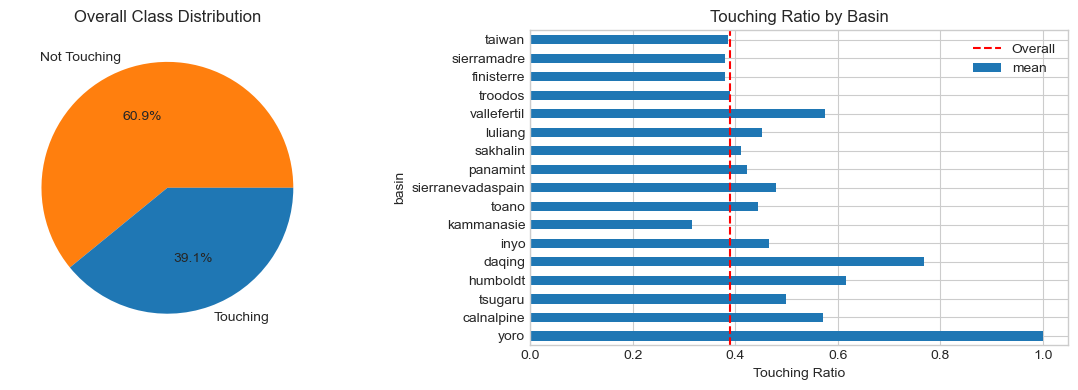

In [4]:
# Overall class balance
print("=== Overall Class Balance ===")
class_counts = df["touching"].value_counts()
print(class_counts)
print(f"\nPositive (touching) ratio: {df['touching'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(class_counts, labels=["Not Touching", "Touching"], autopct="%1.1f%%",
            colors=["#ff7f0e", "#1f77b4"])
axes[0].set_title("Overall Class Distribution")

# Per-basin
basin_stats = df.groupby("basin")["touching"].agg(["count", "mean"]).sort_values("count", ascending=True)
basin_stats["mean"].plot(kind="barh", ax=axes[1], color="#1f77b4")
axes[1].set_xlabel("Touching Ratio")
axes[1].set_title("Touching Ratio by Basin")
axes[1].axvline(df["touching"].mean(), color="red", linestyle="--", label="Overall")
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Per-basin counts
print("\n=== Per-Basin Statistics ===")
basin_summary = df.groupby("basin").agg(
    total=("touching", "count"),
    n_touching=("touching", "sum"),
    ratio=("touching", "mean"),
).sort_values("total", ascending=False)
print(basin_summary)


=== Per-Basin Statistics ===
                   total  n_touching     ratio
basin                                         
taiwan              2729        1054  0.386222
sierramadre         1517         576  0.379697
finisterre          1090         415  0.380734
troodos              154          60  0.389610
vallefertil           80          46  0.575000
luliang               73          33  0.452055
sakhalin              68          28  0.411765
panamint              52          22  0.423077
sierranevadaspain     48          23  0.479167
toano                 27          12  0.444444
kammanasie            19           6  0.315789
inyo                  15           7  0.466667
humboldt              13           8  0.615385
daqing                13          10  0.769231
tsugaru               12           6  0.500000
calnalpine             7           4  0.571429
yoro                   5           5  1.000000


### 2.2 Feature Distributions

In [6]:
# Define feature columns for EDA (all numeric features from the pipeline)
EDA_FEATURE_COLS = [
    # Asymmetry
    "L_1", "L_2", "delta_L",
    # Geometric features
    "orientation_diff_deg",
    "headhead_dist_m", "headhead_dist_norm",
    "apex_angle_deg", "strahler_order_diff",
]

# Check which features exist
available_features = [c for c in EDA_FEATURE_COLS if c in df.columns]
missing = set(EDA_FEATURE_COLS) - set(available_features)
print(f"Available features: {len(available_features)}/{len(EDA_FEATURE_COLS)}")
if missing:
    print(f"Missing: {missing}")

Available features: 8/8


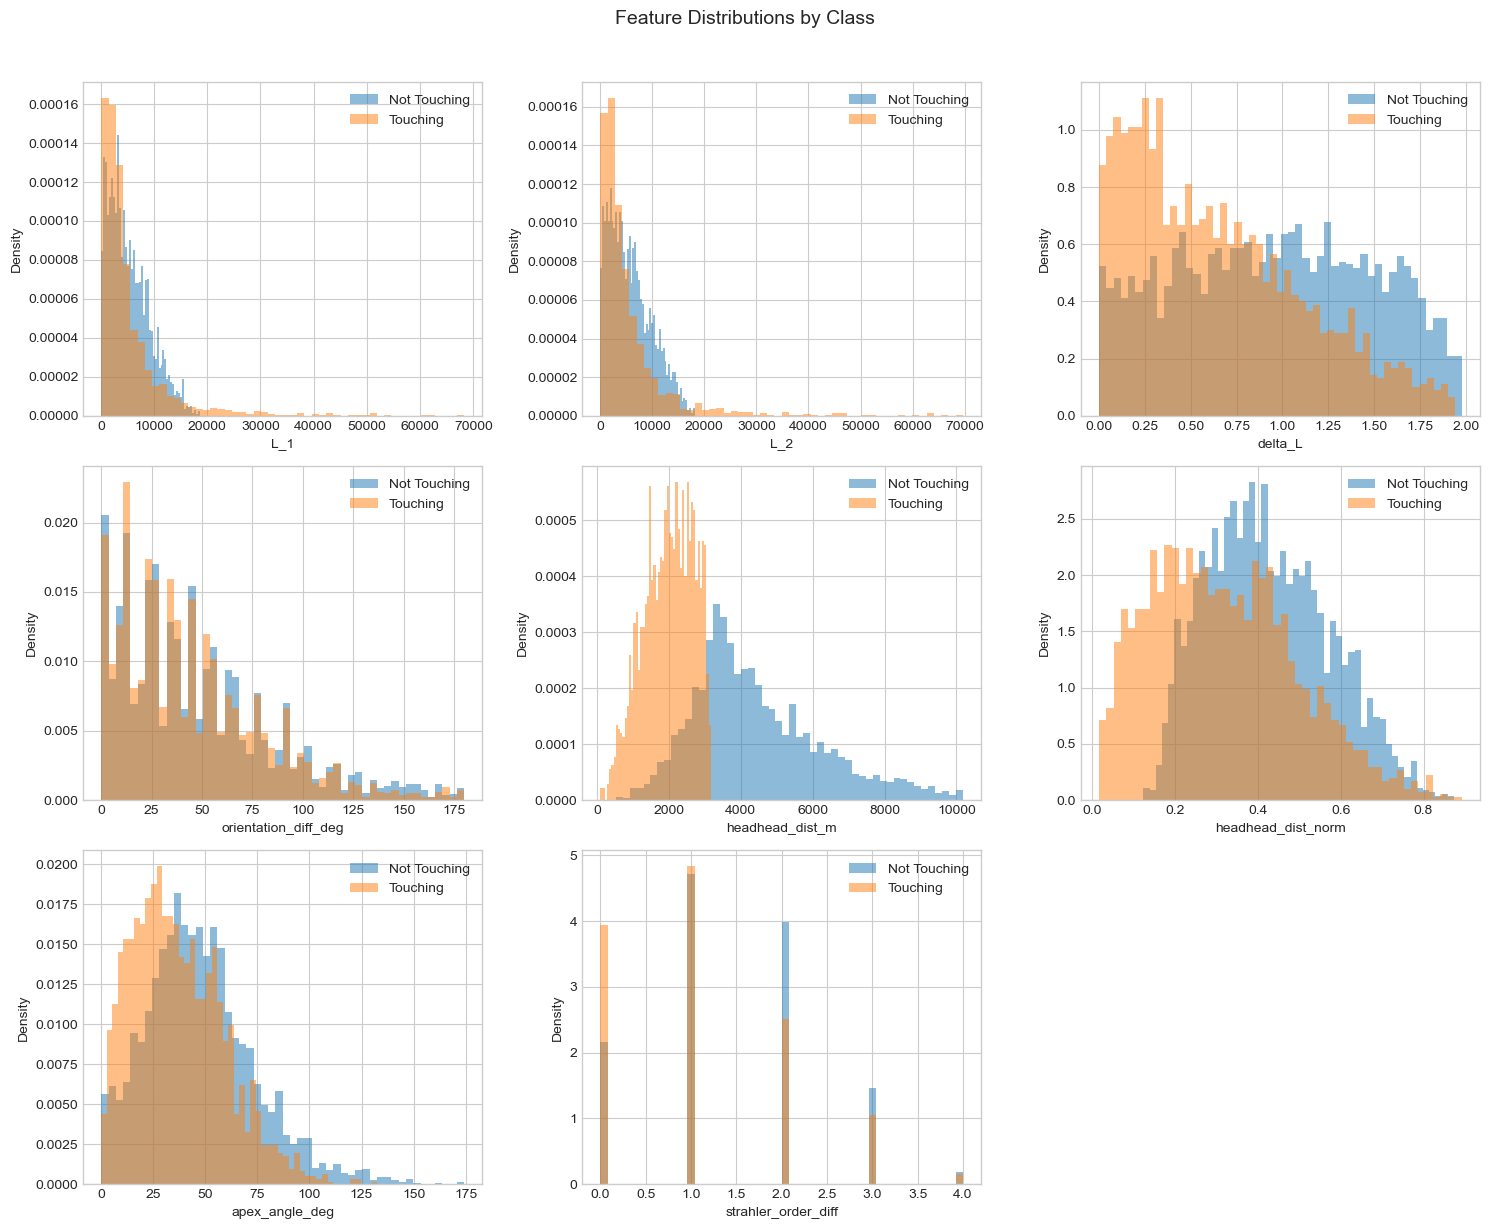

In [7]:
# Feature distributions by class
n_features = len(available_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(available_features):
    ax = axes[i]
    
    # Get data for each class, dropping NaN
    data_0 = df.loc[df["touching"] == False, col].dropna()
    data_1 = df.loc[df["touching"] == True, col].dropna()
    
    if len(data_0) > 0 and len(data_1) > 0:
        ax.hist(data_0, bins=50, alpha=0.5, label="Not Touching", density=True)
        ax.hist(data_1, bins=50, alpha=0.5, label="Touching", density=True)
    
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

# Hide empty subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Feature Distributions by Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Correlation Matrix

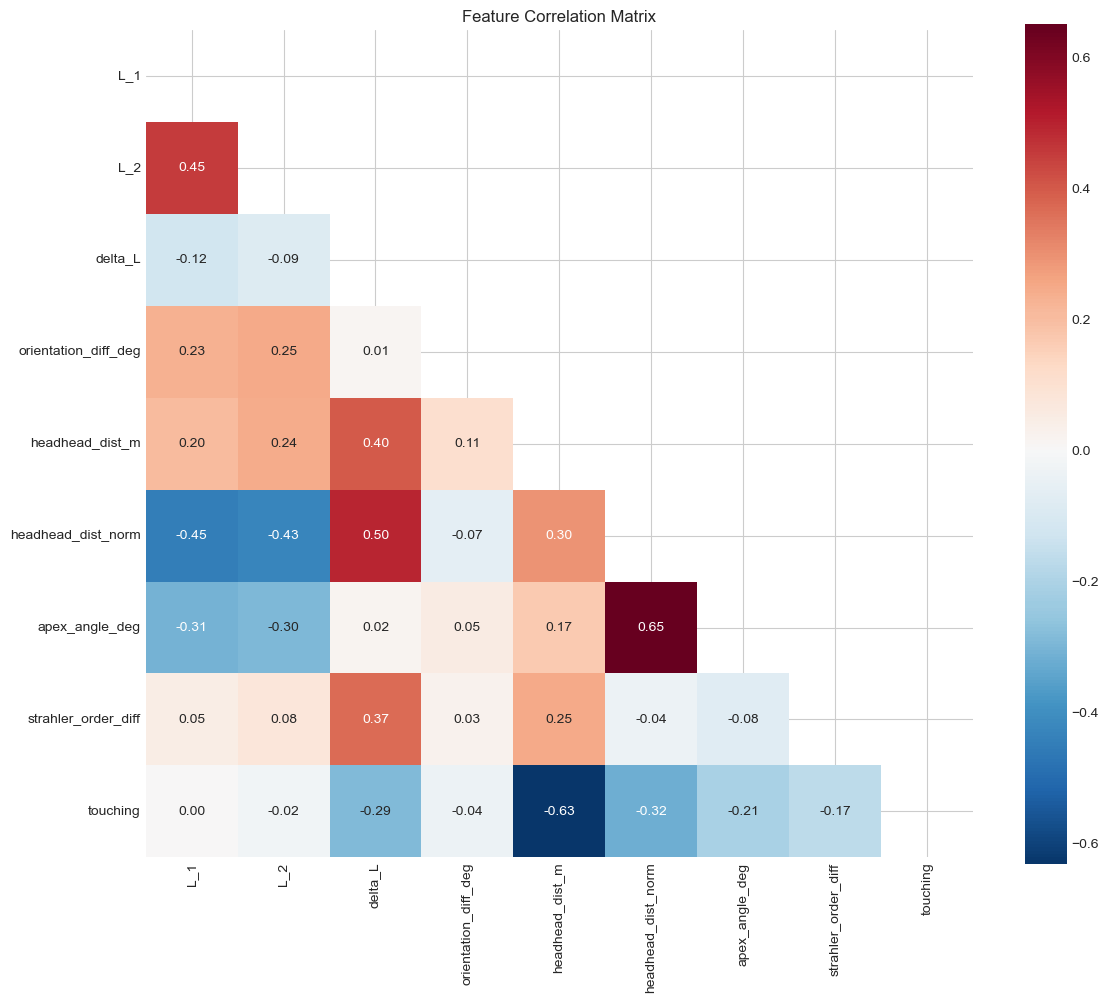


=== Correlation with Target (touching) ===
headhead_dist_m        -0.631826
headhead_dist_norm     -0.320215
delta_L                -0.288565
apex_angle_deg         -0.208545
strahler_order_diff    -0.165879
orientation_diff_deg   -0.039870
L_2                    -0.021146
L_1                     0.002378
Name: touching, dtype: float64


In [8]:
# Correlation matrix
corr_cols = available_features + ["touching"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Correlation with target
print("\n=== Correlation with Target (touching) ===")
target_corr = corr_matrix["touching"].drop("touching").sort_values(key=abs, ascending=False)
print(target_corr)

### 2.4 Missing Values & QC Flags

In [9]:
# Missing values
print("=== Missing Values ===")
missing_info = []
for col in available_features:
    n_missing = df[col].isna().sum()
    pct = n_missing / len(df) * 100
    missing_info.append({"feature": col, "missing": n_missing, "pct": pct})

df_missing = pd.DataFrame(missing_info).sort_values("pct", ascending=False)
print(df_missing.to_string(index=False))

=== Missing Values ===
             feature  missing  pct
                 L_1        0  0.0
                 L_2        0  0.0
             delta_L        0  0.0
orientation_diff_deg        0  0.0
     headhead_dist_m        0  0.0
  headhead_dist_norm        0  0.0
      apex_angle_deg        0  0.0
 strahler_order_diff        0  0.0


In [10]:
# QC flags analysis
if "qc_flags" in df.columns:
    print("\n=== QC Flags ===")
    qc_counts = df["qc_flags"].fillna("").value_counts().head(20)
    print(qc_counts)
    
    n_with_flags = (df["qc_flags"].notna() & (df["qc_flags"] != "")).sum()
    print(f"\nRows with QC flags: {n_with_flags:,} ({n_with_flags/len(df)*100:.1f}%)")


=== QC Flags ===
qc_flags
                                         5767
orient1:short_path                         76
orient2:short_path                         74
orient1:short_path,orient2:short_path       5
Name: count, dtype: int64

Rows with QC flags: 155 (2.6%)


## 3. Preprocessing

In [11]:
### 3.0 Feature Engineering: Tier-1 derived features

# L_ratio: min/max of path lengths — dimensionless, in [0, 1]
# 1 = symmetric lengths; approaches 0 for extreme asymmetry
L_min = df[["L_1", "L_2"]].min(axis=1)
L_max = df[["L_1", "L_2"]].max(axis=1)
df["L_ratio"] = np.where(L_max > 0, L_min / L_max, np.nan)

print("Derived features summary:")
for feat in ["L_ratio"]:
    if feat in df.columns:
        n_nan = df[feat].isna().sum()
        valid = df[feat].dropna()
        if len(valid) > 0:
            print(f"  {feat}: {len(valid):,} valid, {n_nan:,} NaN — "
                  f"mean={valid.mean():.3f}, range=[{valid.min():.3f}, {valid.max():.3f}]")
        else:
            print(f"  {feat}: 0 valid, {n_nan:,} NaN")


Derived features summary:
  L_ratio: 5,922 valid, 0 NaN — mean=0.462, range=[0.005, 1.000]


In [12]:
# Model features: dimensionless/angular features only
# Excludes: size1_px/size2_px (data leakage), contact_px (encodes label),
#           headhead_dist_m (metric — not available for other planetary bodies),
#           delta_L/L_ratio/L_1/L_2 (not usable as classifier features),
#           confluence_angle_deg (removed from analysis),
#           tortuosity_diff/tortuosity_ratio/mean_tortuosity (removed from analysis)
MODEL_FEATURES = [
    "orientation_diff_deg",
    "headhead_dist_norm",
    "apex_angle_deg",
    "strahler_order_diff",
    "proximity_profile_norm",
]

# Filter to available columns (proximity_profile_norm requires regenerating
# master_dataset_v2.csv via notebooks/ml/00_full_pipeline.ipynb)
missing_feats = [f for f in MODEL_FEATURES if f not in df.columns]
if missing_feats:
    print(f"WARNING: features not in dataset and will be skipped: {missing_feats}")
    print("  → Re-run notebooks/ml/00_full_pipeline.ipynb to regenerate master_dataset_v2.csv")
MODEL_FEATURES = [f for f in MODEL_FEATURES if f in df.columns]
print(f"Using {len(MODEL_FEATURES)} features: {MODEL_FEATURES}")


Using 5 features: ['orientation_diff_deg', 'headhead_dist_norm', 'apex_angle_deg', 'strahler_order_diff', 'proximity_profile_norm']


In [13]:
# XGBoost handles NaN natively (learns optimal split direction for missing values).
# Only drop rows where the label or group key is missing.
df_model = df.dropna(subset=["touching", "basin"]).copy()
print(f"Rows after dropping missing label/basin: {len(df_model):,} ({len(df_model)/len(df)*100:.1f}%)")

# Prepare X and y
X = df_model[MODEL_FEATURES]
y = df_model["touching"].astype(int)
groups = df_model["basin"]

print(f"\nX shape: {X.shape}")
print(f"y distribution: {y.value_counts().to_dict()}")
print(f"\nFeature NaN rates:")
for feat in MODEL_FEATURES:
    n_nan = X[feat].isna().sum()
    print(f"  {feat}: {n_nan:,} NaN ({n_nan/len(X)*100:.1f}%)")

Rows after dropping missing label/basin: 5,922 (100.0%)

X shape: (5922, 5)
y distribution: {0: 3607, 1: 2315}

Feature NaN rates:
  orientation_diff_deg: 0 NaN (0.0%)
  headhead_dist_norm: 0 NaN (0.0%)
  apex_angle_deg: 0 NaN (0.0%)
  strahler_order_diff: 0 NaN (0.0%)
  proximity_profile_norm: 0 NaN (0.0%)


### 3.1 Feature Distributions by Class

KDE plots for all model features split by class (touching / not touching).  
Dashed vertical lines mark the class medians. KS statistic (two-sample Kolmogorov–Smirnov) measures how well each feature separates the two classes — higher is better.

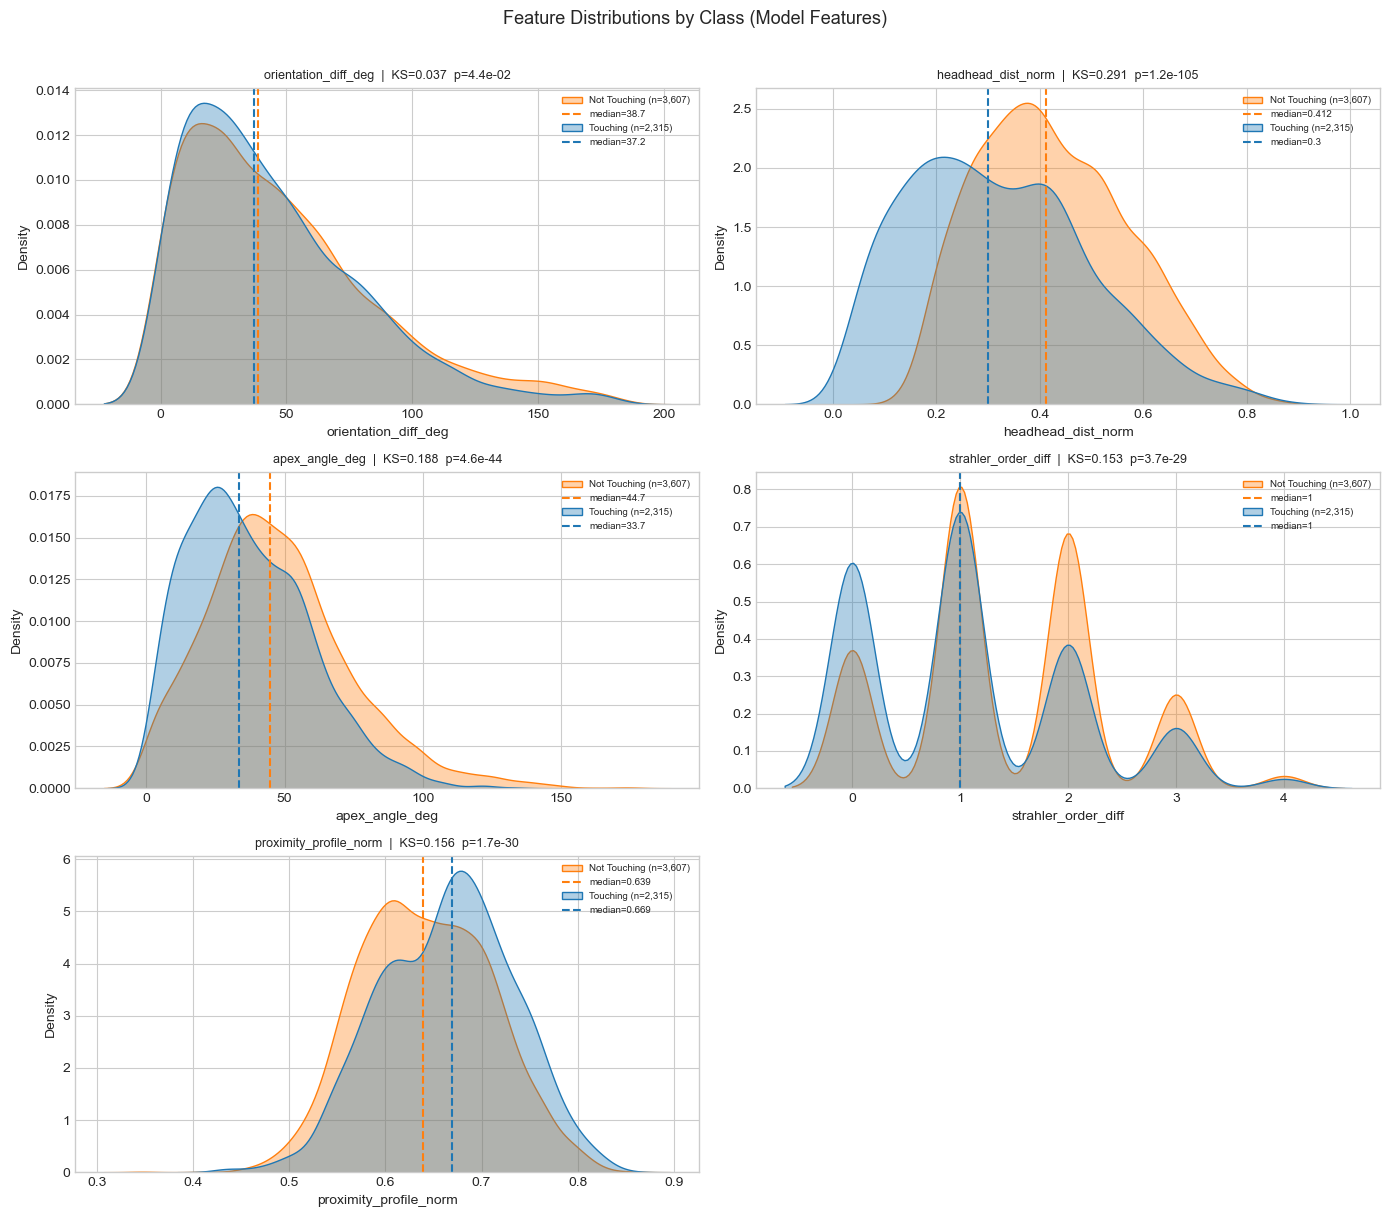


=== Class Separability (KS statistic, higher = better) ===
               feature  median_neg  median_pos  KS_stat     KS_p
    headhead_dist_norm      0.4116      0.3002   0.2908 1.2e-105
        apex_angle_deg     44.6869     33.6901   0.1881  4.6e-44
proximity_profile_norm      0.6390      0.6689   0.1562  1.7e-30
   strahler_order_diff      1.0000      1.0000   0.1527  3.7e-29
  orientation_diff_deg     38.6508     37.2091   0.0367  4.4e-02


In [14]:
from scipy.stats import ks_2samp

PALETTE = {0: "#ff7f0e", 1: "#1f77b4"}
CLASS_LABELS = {0: "Not Touching", 1: "Touching"}

n_feats = len(MODEL_FEATURES)
n_cols = 2
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

summary_rows = []
for i, feat in enumerate(MODEL_FEATURES):
    ax = axes[i]

    data_0 = df_model.loc[df_model["y"] == 0, feat].dropna()
    data_1 = df_model.loc[df_model["y"] == 1, feat].dropna()

    for cls, data in [(0, data_0), (1, data_1)]:
        if len(data) >= 2:
            sns.kdeplot(
                data,
                ax=ax,
                fill=True,
                alpha=0.35,
                color=PALETTE[cls],
                label=f"{CLASS_LABELS[cls]} (n={len(data):,})",
            )
            ax.axvline(data.median(), color=PALETTE[cls], linestyle="--", lw=1.5,
                       label=f"median={data.median():.3g}")

    ks_stat, ks_p = ks_2samp(data_0, data_1)
    ax.set_title(f"{feat}  |  KS={ks_stat:.3f}  p={ks_p:.1e}", fontsize=9)
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc="upper right")

    summary_rows.append({
        "feature": feat,
        "median_neg": data_0.median(),
        "median_pos": data_1.median(),
        "KS_stat": ks_stat,
        "KS_p": ks_p,
    })

for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Class (Model Features)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Separability summary table (sorted by KS statistic)
df_sep = pd.DataFrame(summary_rows).sort_values("KS_stat", ascending=False)
df_sep["KS_p"] = df_sep["KS_p"].map(lambda p: f"{p:.1e}")
print("\n=== Class Separability (KS statistic, higher = better) ===")
print(df_sep.to_string(index=False, float_format="{:.4f}".format))

### 3.2 Train/Test Split by Outlet

Split data at the **outlet** level (unique `basin + outlet` group).
Each outlet is treated as an indivisible unit — all pairs from the same outlet
go entirely to train or test. This keeps ~20 % of outlets for the test set
while allowing outlets from every basin (including Taiwan) to appear in training.

In [15]:
# Build unique outlet groups: 'basin__outlet'
df_model["outlet_group"] = df_model["basin"] + "__" + df_model["outlet"].astype(str)
outlet_groups = df_model["outlet_group"]

# GroupShuffleSplit: keeps every outlet entirely in train or test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=outlet_groups))

n_total_outlets = outlet_groups.nunique()
n_test_outlets  = outlet_groups.iloc[test_idx].nunique()
print(f"Total outlets:  {n_total_outlets:,}")
print(f"Test outlets:   {n_test_outlets:,} ({n_test_outlets/n_total_outlets*100:.1f}%)")
print(f"Test rows:      {len(test_idx):,} ({len(test_idx)/len(df_model)*100:.1f}%)")


Total outlets:  396
Test outlets:   80 (20.2%)
Test rows:      1,788 (30.2%)


In [16]:
# Create train/test split
train_mask = df_model.index.isin(df_model.index[train_idx])
test_mask  = df_model.index.isin(df_model.index[test_idx])

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
outlet_groups_train = outlet_groups[train_mask]
groups_train = groups[train_mask]  # basin labels for display

print(f"Train: {len(X_train):,} rows, {y_train.mean():.1%} positive")
print(f"Test:  {len(X_test):,} rows, {y_test.mean():.1%} positive")
print(f"\nTrain basins: {groups_train.nunique()} (all {groups.nunique()} basins represented)")
print(f"Test  basins: {groups[test_mask].nunique()}")


Train: 4,134 rows, 39.5% positive
Test:  1,788 rows, 38.1% positive

Train basins: 17 (all 17 basins represented)
Test  basins: 17


## 4. Model Training

### Strategy for improving precision on the positive class (touching)
1. **Hyperparameter tuning** via RandomizedSearchCV scored on `precision` (class 1)
2. **scale_pos_weight** for class imbalance
3. **StratifiedKFold** cross-validation with multiple metrics
4. **Threshold tuning** on the precision-recall curve to raise precision further

In [17]:
# Compute scale_pos_weight for class imbalance
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


scale_pos_weight: 1.53


In [18]:
# --- Hyperparameter tuning via RandomizedSearchCV ---
# Scoring: precision for class 1 (the metric we want to maximize)

param_distributions = {
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.29),       # [0.01, 0.30)
    "n_estimators": randint(100, 500),
    "gamma": uniform(0, 5),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.5, 0.5),             # [0.5, 1.0)
    "colsample_bytree": uniform(0.5, 0.5),      # [0.5, 1.0)
}

base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="aucpr",
    tree_method="hist",
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_distributions,
    n_iter=80,
    scoring="precision",        # optimize precision for class 1
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

search.fit(X_train, y_train)

model = search.best_estimator_
print(f"\nBest CV precision (class 1): {search.best_score_:.3f}")
print(f"\nBest hyperparameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best CV precision (class 1): 0.615

Best hyperparameters:
  colsample_bytree: 0.5061
  gamma: 4.8494
  learning_rate: 0.0225
  max_depth: 7
  min_child_weight: 6
  n_estimators: 312
  subsample: 0.9965


In [19]:
# --- Cross-validation: StratifiedKFold (stratified) + GroupKFold (spatial) ---

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

# 1. StratifiedKFold — ensures balanced class splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_strat = cross_validate(
    model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1
)

print("=== StratifiedKFold CV (5-fold) ===")
for metric in scoring:
    vals = cv_strat[f"test_{metric}"]
    print(f"  {metric:>12s}: {vals.mean():.3f} ± {vals.std():.3f}")

# 2. GroupKFold — respects outlet boundaries (no intra-outlet leakage)
gkf = GroupKFold(n_splits=5)
cv_group = cross_validate(
    model, X_train, y_train, groups=outlet_groups_train, cv=gkf, scoring=scoring, n_jobs=-1
)

print("\n=== GroupKFold CV (by outlet, 5-fold) ===")
for metric in scoring:
    vals = cv_group[f"test_{metric}"]
    print(f"  {metric:>12s}: {vals.mean():.3f} ± {vals.std():.3f}")

=== StratifiedKFold CV (5-fold) ===
     precision: 0.615 ± 0.022
        recall: 0.674 ± 0.025
            f1: 0.643 ± 0.022
       roc_auc: 0.775 ± 0.010
        pr_auc: 0.718 ± 0.014

=== GroupKFold CV (by outlet, 5-fold) ===
     precision: 0.613 ± 0.012
        recall: 0.681 ± 0.016
            f1: 0.645 ± 0.009
       roc_auc: 0.776 ± 0.009
        pr_auc: 0.718 ± 0.021


## 5. Evaluation

In [20]:
# --- Test set evaluation at default threshold (0.5) ---
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_pred_proba >= 0.5).astype(int)

print("=== Test Set — Default Threshold (0.5) ===")
print(f"Accuracy:        {accuracy_score(y_test, y_pred_default):.3f}")
print(f"Precision (cls1): {precision_score(y_test, y_pred_default):.3f}")
print(f"Recall (cls1):    {recall_score(y_test, y_pred_default):.3f}")
print(f"F1 (cls1):        {f1_score(y_test, y_pred_default):.3f}")
print(f"ROC AUC:          {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"PR AUC:           {average_precision_score(y_test, y_pred_proba):.3f}")
print(f"\n{classification_report(y_test, y_pred_default)}")

=== Test Set — Default Threshold (0.5) ===
Accuracy:        0.694
Precision (cls1): 0.585
Recall (cls1):    0.682
F1 (cls1):        0.630
ROC AUC:          0.762
PR AUC:           0.705

              precision    recall  f1-score   support

           0       0.78      0.70      0.74      1106
           1       0.58      0.68      0.63       682

    accuracy                           0.69      1788
   macro avg       0.68      0.69      0.68      1788
weighted avg       0.71      0.69      0.70      1788



### 5.1 Threshold Tuning for Precision

Instead of the default 0.5 cutoff, sweep thresholds on the precision-recall curve and
pick one that **maximizes precision while keeping recall ≥ 0.50**.

In [21]:
# --- Threshold tuning on precision-recall curve ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Find threshold that maximizes precision subject to recall >= MIN_RECALL
MIN_RECALL = 0.50

# precisions and recalls have len = len(thresholds) + 1; trim last element
valid_mask = recalls[:-1] >= MIN_RECALL
if valid_mask.any():
    # Among thresholds where recall is acceptable, pick highest precision
    best_idx = np.argmax(precisions[:-1][valid_mask])
    # Map back to original index
    orig_indices = np.where(valid_mask)[0]
    best_idx = orig_indices[best_idx]
    optimal_threshold = thresholds[best_idx]
    print(f"Optimal threshold: {optimal_threshold:.3f}")
    print(f"  → Precision: {precisions[best_idx]:.3f}")
    print(f"  → Recall:    {recalls[best_idx]:.3f}")
else:
    optimal_threshold = 0.5
    print("No threshold found with recall >= {MIN_RECALL}, using 0.5")

# Apply optimal threshold
y_pred_tuned = (y_pred_proba >= optimal_threshold).astype(int)

print(f"\n=== Test Set — Tuned Threshold ({optimal_threshold:.3f}) ===")
print(f"Accuracy:         {accuracy_score(y_test, y_pred_tuned):.3f}")
print(f"Precision (cls1): {precision_score(y_test, y_pred_tuned):.3f}")
print(f"Recall (cls1):    {recall_score(y_test, y_pred_tuned):.3f}")
print(f"F1 (cls1):        {f1_score(y_test, y_pred_tuned):.3f}")
print(f"ROC AUC:          {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"PR AUC:           {average_precision_score(y_test, y_pred_proba):.3f}")
print(f"\n{classification_report(y_test, y_pred_tuned)}")

# Use tuned predictions for downstream plots
y_pred = y_pred_tuned

Optimal threshold: 0.577
  → Precision: 0.661
  → Recall:    0.500

=== Test Set — Tuned Threshold (0.577) ===
Accuracy:         0.711
Precision (cls1): 0.661
Recall (cls1):    0.500
F1 (cls1):        0.569
ROC AUC:          0.762
PR AUC:           0.705

              precision    recall  f1-score   support

           0       0.73      0.84      0.78      1106
           1       0.66      0.50      0.57       682

    accuracy                           0.71      1788
   macro avg       0.70      0.67      0.68      1788
weighted avg       0.70      0.71      0.70      1788



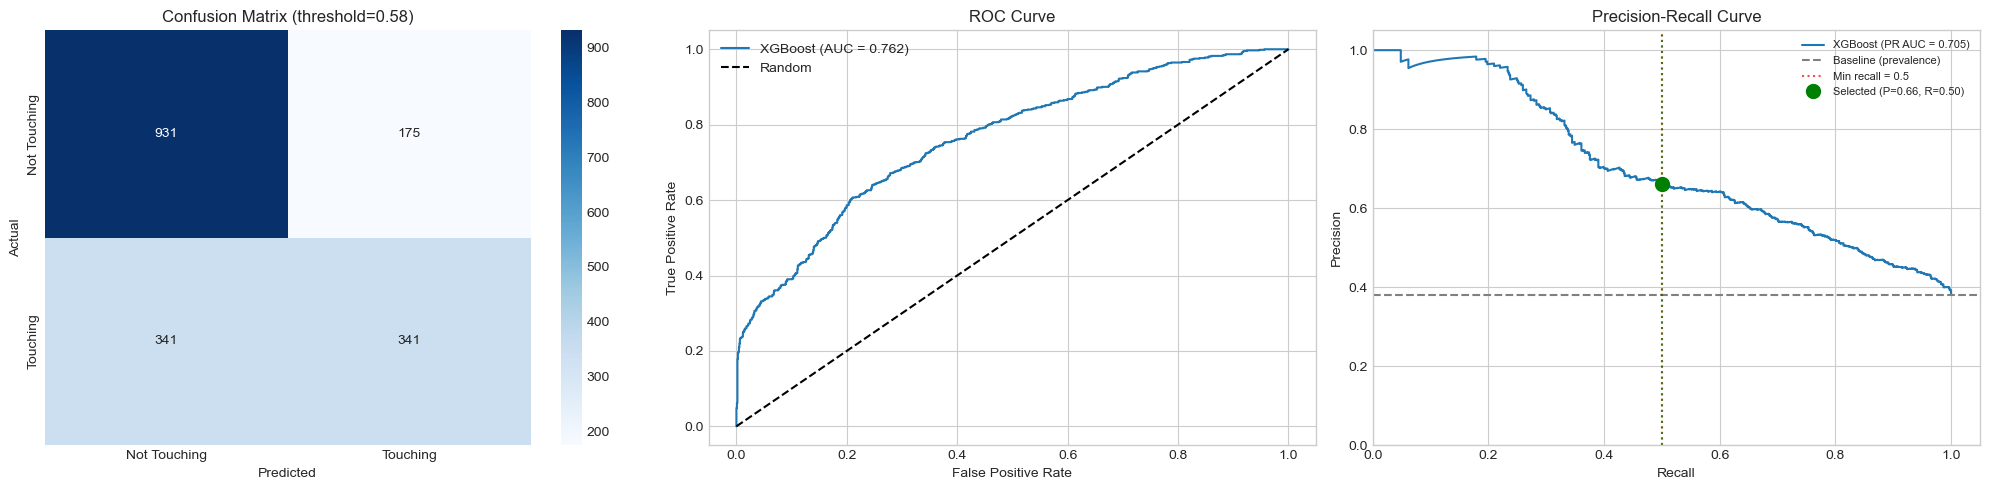

In [22]:
# --- Plots: Confusion Matrix, ROC Curve, Precision-Recall Curve ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion matrix (tuned threshold)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not Touching", "Touching"],
            yticklabels=["Not Touching", "Touching"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix (threshold={optimal_threshold:.2f})")

# 2. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# 3. Precision-Recall curve
pr_auc = average_precision_score(y_test, y_pred_proba)
axes[2].plot(recalls, precisions, label=f"XGBoost (PR AUC = {pr_auc:.3f})")
axes[2].axhline(y_test.mean(), color="gray", linestyle="--", label="Baseline (prevalence)")
axes[2].axvline(MIN_RECALL, color="red", linestyle=":", alpha=0.7, label=f"Min recall = {MIN_RECALL}")
axes[2].axvline(recalls[best_idx], color="green", linestyle=":", alpha=0.7)
axes[2].plot(recalls[best_idx], precisions[best_idx], "go", markersize=10,
             label=f"Selected (P={precisions[best_idx]:.2f}, R={recalls[best_idx]:.2f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlim([0, 1.05])
axes[2].set_ylim([0, 1.05])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.2 Feature Importance

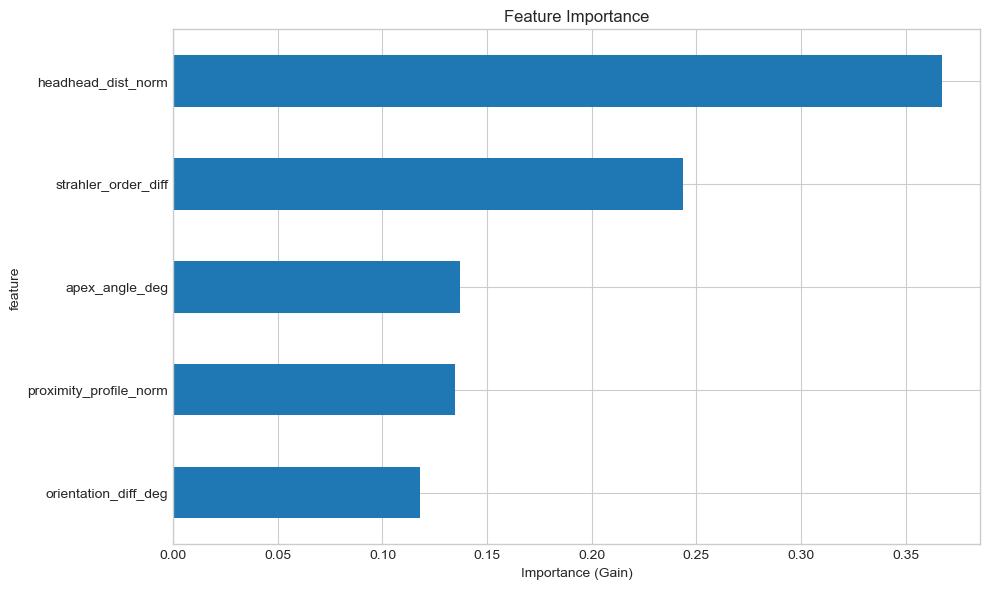


Feature Importance (sorted):
               feature  importance
    headhead_dist_norm    0.367175
   strahler_order_diff    0.243465
        apex_angle_deg    0.137051
proximity_profile_norm    0.134529
  orientation_diff_deg    0.117781


In [23]:
# Feature importance (gain)
importance = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", x="feature", y="importance", ax=ax, legend=False)
ax.set_xlabel("Importance (Gain)")
ax.set_title("Feature Importance")
plt.tight_layout()
plt.show()

print("\nFeature Importance (sorted):")
print(importance.sort_values("importance", ascending=False).to_string(index=False))

### 5.3 Per-Basin Performance

In [24]:
# Per-basin performance (test set only)
df_test = df_model[test_mask].copy()
df_test["y_pred"] = y_pred
df_test["y_pred_proba"] = y_pred_proba

print("=== Per-Basin Performance (Test Set) ===")
for basin in sorted(df_test["basin"].unique()):
    basin_data = df_test[df_test["basin"] == basin]
    if len(basin_data) > 10:
        y_true_basin = basin_data["touching"].astype(int)
        y_pred_basin = basin_data["y_pred"]
        y_proba_basin = basin_data["y_pred_proba"]

        acc = accuracy_score(y_true_basin, y_pred_basin)
        try:
            auc = roc_auc_score(y_true_basin, y_proba_basin)
        except ValueError:
            auc = float("nan")  # Only one class present

        n_outlets = basin_data["outlet"].nunique()
        print(f"  {basin}: n={len(basin_data)}, outlets={n_outlets}, accuracy={acc:.3f}, AUC={auc:.3f}")


=== Per-Basin Performance (Test Set) ===
  finisterre: n=301, outlets=17, accuracy=0.694, AUC=0.734
  luliang: n=15, outlets=5, accuracy=0.733, AUC=0.893
  sakhalin: n=13, outlets=3, accuracy=0.692, AUC=0.875
  sierramadre: n=596, outlets=14, accuracy=0.718, AUC=0.771
  taiwan: n=790, outlets=16, accuracy=0.711, AUC=0.756
  troodos: n=31, outlets=2, accuracy=0.677, AUC=0.729


## 6. Export Model

In [25]:
# Save model
model_dir = PROJECT_ROOT / "models"
model_dir.mkdir(exist_ok=True)

model_path = model_dir / "xgb_touching_classifier.json"
model.save_model(str(model_path))
print(f"Model saved to: {model_path}")

Model saved to: /Users/guypi/Projects/channel-heads/models/xgb_touching_classifier.json


In [26]:
# Save feature list and optimal threshold
feature_path = model_dir / "feature_columns.txt"
with open(feature_path, "w") as f:
    f.write("\n".join(MODEL_FEATURES))
print(f"Feature list saved to: {feature_path}")

threshold_path = model_dir / "optimal_threshold.txt"
with open(threshold_path, "w") as f:
    f.write(f"{optimal_threshold:.6f}\n")
print(f"Optimal threshold saved to: {threshold_path}")

Feature list saved to: /Users/guypi/Projects/channel-heads/models/feature_columns.txt
Optimal threshold saved to: /Users/guypi/Projects/channel-heads/models/optimal_threshold.txt


In [27]:
# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Dataset size:       {len(df_model):,} rows")
print(f"Features:           {len(MODEL_FEATURES)}")
print(f"Train/test split:   by outlet (80/20 GroupShuffleSplit)")
print(f"scale_pos_weight:   {scale_pos_weight:.2f}")
print(f"Tuned threshold:    {optimal_threshold:.3f}")

print(f"\n--- Cross-Validation (StratifiedKFold) ---")
for metric in scoring:
    vals = cv_strat[f"test_{metric}"]
    print(f"  {metric:>12s}: {vals.mean():.3f} ± {vals.std():.3f}")

print(f"\n--- Test Set (threshold={optimal_threshold:.3f}) ---")
print(f"  Precision (cls1): {precision_score(y_test, y_pred):.3f}")
print(f"  Recall (cls1):    {recall_score(y_test, y_pred):.3f}")
print(f"  F1 (cls1):        {f1_score(y_test, y_pred):.3f}")
print(f"  ROC AUC:          {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"  PR AUC:           {average_precision_score(y_test, y_pred_proba):.3f}")
print(f"  Accuracy:         {accuracy_score(y_test, y_pred):.3f}")

print(f"\nBest hyperparameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print(f"\nModel saved to:     {model_path}")
print(f"Threshold saved to: {threshold_path}")


SUMMARY
Dataset size:       5,922 rows
Features:           5
Train/test split:   by outlet (80/20 GroupShuffleSplit)
scale_pos_weight:   1.53
Tuned threshold:    0.577

--- Cross-Validation (StratifiedKFold) ---
     precision: 0.615 ± 0.022
        recall: 0.674 ± 0.025
            f1: 0.643 ± 0.022
       roc_auc: 0.775 ± 0.010
        pr_auc: 0.718 ± 0.014

--- Test Set (threshold=0.577) ---
  Precision (cls1): 0.661
  Recall (cls1):    0.500
  F1 (cls1):        0.569
  ROC AUC:          0.762
  PR AUC:           0.705
  Accuracy:         0.711

Best hyperparameters:
  colsample_bytree: 0.5061
  gamma: 4.8494
  learning_rate: 0.0225
  max_depth: 7
  min_child_weight: 6
  n_estimators: 312
  subsample: 0.9965

Model saved to:     /Users/guypi/Projects/channel-heads/models/xgb_touching_classifier.json
Threshold saved to: /Users/guypi/Projects/channel-heads/models/optimal_threshold.txt
